# Взгляд в MCMC

In [1]:
#all imports here pls
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm import tqdm
import collections
import re

import copy

import cv2# для последнего задания, устанавливается pip install opencv-python
from skimage.draw import line as skline#pip install skimage

from IPython.display import clear_output



## Ещё о картинках

Вообще MCMC -- отличное средство для художественных эффектов, учитывая, что мы гибко и более-менее свободно контролируем пропоузал. В частности, то, что мы решали раньше с помощью ULArtist можно теперь сделать и с помощью RWMH, только с немного другой идеей.

Вообще пропоузал на гауссовском случайном блуждании хорош тем, что он симметричный: поэтому вероятность принять семпл будет равна

$$
a(X' \vert X_t) = 1 \wedge \frac{\pi_{X'}}{\pi_{X_t}}.
$$

По этой причине мы можем построить алгоритм RWMH на основе гауссовского случайного блуждания

$$
Z_{t+1} = \mathrm{clip}(\mathrm{round}(Z_t + \varepsilon_{t+1})), \quad \varepsilon_{t} \sim^{iid} N(0,\sigma^2)
$$

с клипом по границам картинки и округлением в качестве пропоузала и дальше действовать по обозначенной ранее схеме. Единственное место, где пропоузал несимметричный -- это на границе. Но формально если нам в качестве пропоузала генерируется граница, то вероятность принять её равна нулю (если предполагаем нулевую вероятность вне границ картинки).

Что ещё важно насчёт вероятности принятия: если новая точка более вероятна, то есть $\pi_{X'}>\pi_{X}$, то семпл принимается. Если нет, то он всё ещё может приняться с вероятностью больше 0, и тем менее вероятно, чем меньше $\pi_{X'}$. Это сдерживает цепь от того, чтобы часто покидать окрестность моды.


In [6]:
class SampleArtist:
    
    def __init__(self, img):
        '''
            float[] img: opencv img (height,width,3), RGB
        '''
        self.img = img
        self.imgDims = self.img.shape[:2]


    def genNewPixel(self):
        """Generates new pixel 

        Args:
           

        Returns:
            float[] newPixel
        """        
        return NotImplementedError
    
    
    def imgTransformer(self):
        """Uses an algorithm to design a drawing path

        Args:
            
        Returns:
            list of float[], points of the random walk
        """    

        return NotImplementedError


    def sampleInitialPoint(self):
        '''
        Gives a point to begin sampling from.
        '''
        return NotImplementedError
    

    def drawTraj(self, imgNew, sampleList, blend, pointRadius, lineWidth, onlyPoints=False,**kwargs):
        """Draws a trajectory onto canvas given by imgNew

        Args:
            imgNew float[]: image to draw on (openCV)
            sampleList list(float[]): list of visited points
            blend (bool): to draw line gradient(True) or not 
            pointRadius (int): point size
            lineWidth (int):  line width
            onlyPoints (bool): whether to draw onlyPoints
        """        
        if blend:#if so, add a color gradient to the line
            imgX = sampleList[0][0]
            imgY = sampleList[0][1]
            imgNew = cv2.circle(imgNew, (imgX,imgY) ,
                                        radius=5,
                                        color=(255,0,0),
                                        thickness=-1)
            for i in tqdm(np.arange(len(sampleList)-1), desc='Rendering Blended'):
                # Grab colors of start and end pixels
                
                imgXStart = sampleList[i][0]
                imgYStart = sampleList[i][1]
                
                imgXEnd = sampleList[i+1][0]
                imgYEnd = sampleList[i+1][1]
                
                startColor = self.img[imgXStart, imgYStart, :]
                endColor = self.img[imgXEnd, imgYEnd, :]

                # Render a dot
                imgNew = cv2.circle(imgNew, sampleList[i],
                                        radius=pointRadius,
                                        color=tuple([int(x) for x in startColor]),
                                        thickness=-1)

                if(not onlyPoints):
                    # Prepare a line
                    newLine = list(zip(*skline(*sampleList[i], *sampleList[i+1])))#color gradient
                    blender = np.linspace(0, 1, len(newLine))

                    startColor = np.array(startColor)
                    endColor = np.array(endColor)
                    colorMix = startColor[:, np.newaxis] * \
                        (1-blender) + endColor[:, np.newaxis]*blender
                    colorMix = colorMix.astype(np.uint8).transpose()

                    # render the line
                    for j in range(len(newLine)):
                        imgNew[newLine[j][::-1]] = colorMix[j]
        else:

            for i in tqdm(np.arange(len(sampleList)-1), desc='Rendering'):
                # Grab color of starting pixel
                imgX = sampleList[i][0]
                imgY = sampleList[i][1]
                img_color = self.img[imgX, imgY, :]
                img_color = tuple([int(x) for x in img_color])

                # Render dots and lines to canvas
                imgNew = cv2.circle(imgNew, sampleList[i],
                                        radius=pointRadius,
                                        color=img_color,
                                        thickness=-1)
                if(not onlyPoints):
                    imgNew = cv2.line(imgNew, sampleList[i], sampleList[i+1],
                                    img_color, lineWidth)
                
                

    def drawImage(self, outputFilename, nIterations, 
                  pointRadius=1,
                  lineWidth=1,
                  blend=False,
                  Ntrajs=10,
                  **kwargs
                  ):
        """Draws an mcmcfied picture onto new canvas

        Args:
            outputFilename str: Path to save output image
            nIterations int: number of steps in one trajectory
            pointRadius (int, optional): size of the point on canvas (openCV has minimal size 1). Defaults to 1.
            lineWidth (int, optional): width of the line on canvas (openCV has minimal width 1). Defaults to 1.
            blend (bool, optional): whether to use color gradient on the lines. Defaults to False.
            nLists (int, optional): number of trajectories. Defaults to 10.

        Raises:
            Exception: _description_
        """        
        
        #canvas init
        imgNew = 128*np.ones((self.imgDims[1], self.imgDims[0], 3), np.uint8)
        for j in np.arange(Ntrajs):
            print(f"{j+1} trajs of {Ntrajs} processing....")
            
            #sample starting point
            initialPoint = self.sampleInitialPoint()
            
            #construct trajectory
            sampleList = self.imgTransformer(initialPoint, nIterations, **kwargs)
            
            #round it (opencv requires int)
            sampleList = [ tuple(np.ceil(sampleList[i]).astype("int32").reshape(1,-1)[0]-1) for i in np.arange(len(sampleList))]
            
            #draw the trajectory onto the canvas
            self.drawTraj(imgNew, sampleList, blend, pointRadius, lineWidth,**kwargs)    
            
        print("DONE")

        # Export image
        imgNew = np.swapaxes(imgNew[:, :, :], 0, 1)
        if not cv2.imwrite(outputFilename, imgNew):
            raise Exception("Could not write image.")
        else:
            print('Image saved to '+outputFilename)

In [7]:
class RWMHSampleArtist(SampleArtist):
    
    def __init__(self, img, brightnessDensity):
        '''
            float[] img: opencv img (height,width,3), RGB
        '''
        super(RWMHSampleArtist, self).__init__(img)
        self.brightnessDensity = brightnessDensity


    def genNewPixel(self,loc,scale):
        """Generates new pixel starting from loc with variance scale

        Args:
            loc float[]: start (2,)
            t float: time
            delta float: time step

        Returns:
            float[] newPixel
        """        
        newPixel = tuple(int(round(i))
                              for i in np.random.normal(loc, scale))
        newPixel = np.round(newPixel).astype("int32")
        newPixel = np.array([np.clip(newPixel[0],0,self.imgDims[0]-1),np.clip(newPixel[1],0,self.imgDims[1]-1)])
        return newPixel
    
    def imgTransformer(self, initialPoint, nIterations, scale=100, takeEvery=1, startAt=0, **kwargs):
        """Uses RWMH algorithm to design a drawing path

        Args:
            initialPoint float[][]: point to start the walk
            nIterations int: number of steps in the trajectory
            scale float: variance parameter of random walk
            int takeEvery: how often to collect samples
            int startAt: when to start collecting samples

        Returns:
            list of float[], points of the random walk
        """    

        # Preallocation and obtaining useful information from the input args
        sampleList = []
        #sampleList[0] = np.round(initialPoint).astype("int32")
        prev = np.round(initialPoint).astype("int32")
        # Generate samples from brightnessDensity in terms of pixel locations
        for i in tqdm(range(nIterations), desc='Sampling'):
            newPixel = self.genNewPixel(prev, scale)
            
            #needed?
            #while(np.linalg.norm(newPixel-sampleList[i])<=1e-8):
            #    #if converged on border, then punch the particle
            #    start = sampleList[i] + np.random.normal(size=(2,))*10
            #    start = np.array([np.clip(start[0],0,self.imgDims[0]),np.clip(start[1],0,self.imgDims[1])])
            #    newPixel = self.genNewPixel(start, scale)
            
            ratio1 = self.brightnessDensity[newPixel[0],newPixel[1]]/self.brightnessDensity[prev[0],prev[1]]
            
            
            accept_prob = min(1, ratio1)

            # Decide whether to accept or reject the new pixel location
            pixelUpd = 0
            if (np.random.random() < accept_prob):
                pixelUpd = newPixel
            else:
                pixelUpd = prev
            #print("NP",newPixel)
            if(i>startAt):
                if((i-startAt)%takeEvery ==0):
                    sampleList.append(pixelUpd)
            prev = pixelUpd

        return sampleList
    
    def sampleInitialPoint(self):
        '''
        Gives a point to begin sampling from.
        '''
        ylim, xlim = self.imgDims
        initialPoint = np.random.multivariate_normal(mean=np.array([ylim/2,xlim/2]),cov=np.eye(2)*100)
        initialPoint = np.clip(initialPoint, 0, [xlim, ylim])
        return initialPoint
    
def read_image(filename):
        """Reads an image and returns a RGB image. If the imported image has an alpha channel, this is
        blended as if there were a white canvas underneath in order to give
        a RGB image

        Args:
            filename (str): filename to open (path to filename)

        Returns:
            Obj: opencv img
        """        
        
        # Import in the image
        img = cv2.imread(filename, cv2.IMREAD_UNCHANGED)

        # Handle transparency
        if (img.shape[2] == 4):
            img_rgb = img[:, :, :3]
            img_alpha = img[:, :, 3]

            alpha = img_alpha[:, :, np.newaxis].astype(np.float32) / 255.0
            alpha = np.concatenate((alpha, alpha, alpha), axis=2)

            img = img_rgb.astype(np.float32)*alpha + \
                np.ones_like(img_rgb)*255*(1-alpha)
            img = img.astype(np.uint8)

        return img

In [8]:
inputFilename="./HSE.jpg"
img = read_image(inputFilename)
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
brightnessDensity = np.mean(imgRGB,axis=-1)/255#lightness map

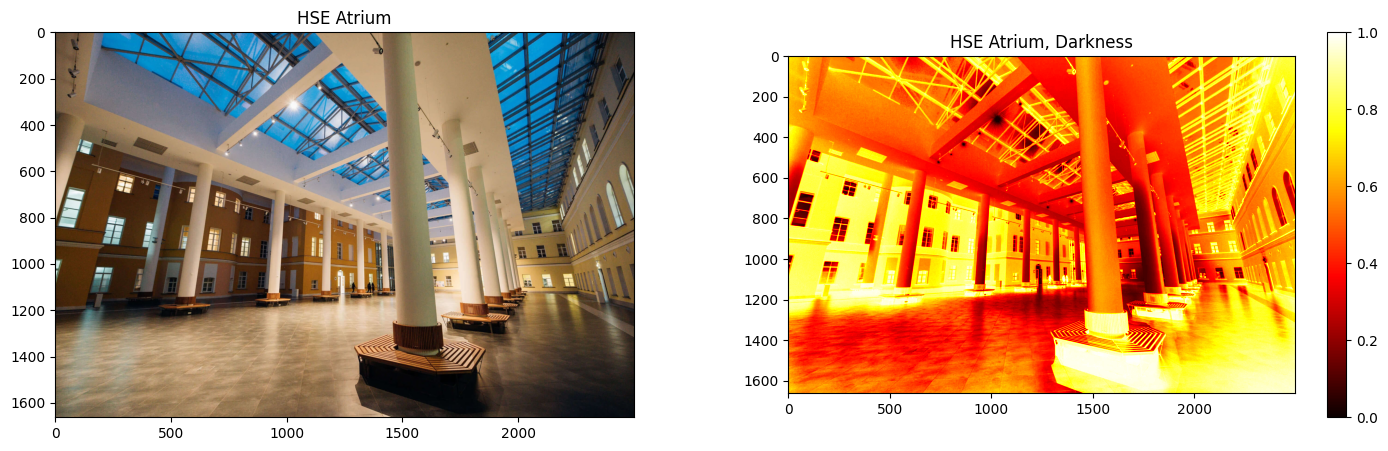

In [9]:
f, (ax1,ax2) = plt.subplots(1,2,figsize=(18,5))

ax1.set_title("HSE Atrium")
ax1.imshow(imgRGB)

ax2.set_title("HSE Atrium, Darkness")
im2=ax2.imshow(1-brightnessDensity,cmap='hot')
plt.colorbar(im2, ax=ax2)

Попробуем теперь запустить!

In [10]:
inputFilename="./py.jpg"#"./test-images/HSE.jpg"#"./test-images/bbridge.jpg"
outputFilename="./pyfied.jpg"
nIterations=200000
Ntrajs = 1
img = read_image(inputFilename)
#img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)#since opencv permutes channels to BGR, remove if colors are wrong

brightnessDensity = 1-np.mean(img,axis=-1)/255#darkness map
#brightnessDensity = np.mean(img,axis=-1)/255#brightness map

delta = 0.1

nAnchors = 1000
sigma=200
sigmaNoise=220
blend=True

artist = RWMHSampleArtist(img,brightnessDensity)

In [11]:
artist.drawImage(outputFilename,nIterations, Ntrajs=Ntrajs,blend=blend, scale=10)

1 trajs of 1 processing....


Rendering Blended: 100%|██████████| 199998/199998 [00:11<00:00, 17666.22it/s]

DONE
Image saved to ./pyfied.jpg


In [12]:
img = read_image(inputFilename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)#since opencv permutes channels to BGR, remove if colors are wrong
img2 = read_image(outputFilename)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)#since opencv permutes channels to BGR, remove if colors are wrong

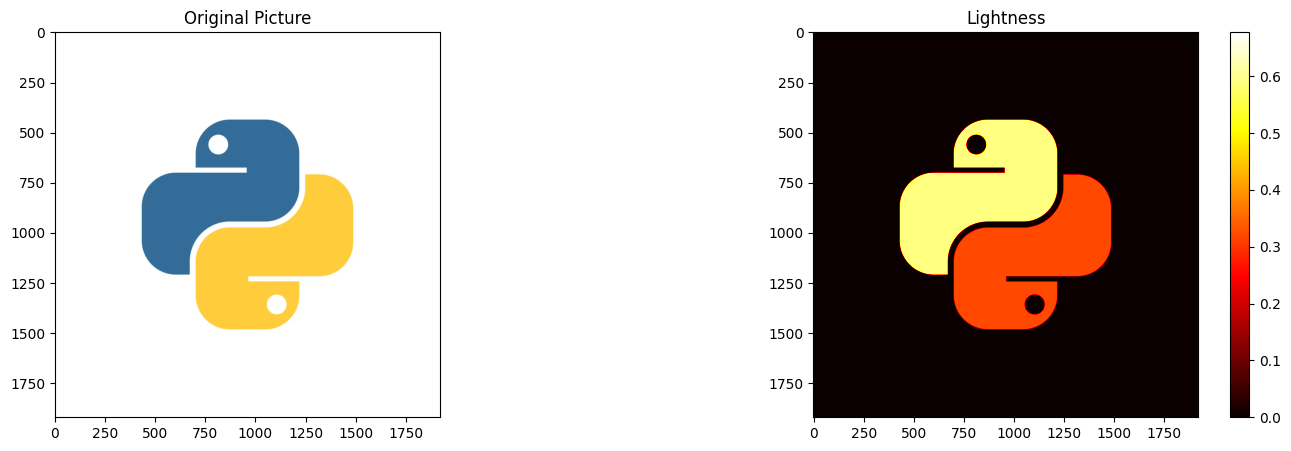

In [13]:
f, (ax1,ax2) = plt.subplots(1,2,figsize=(18,5))

ax1.set_title("Original Picture")
ax1.imshow(img)

ax2.set_title("Lightness")
im2=ax2.imshow(brightnessDensity,cmap='hot')
plt.colorbar(im2, ax=ax2)

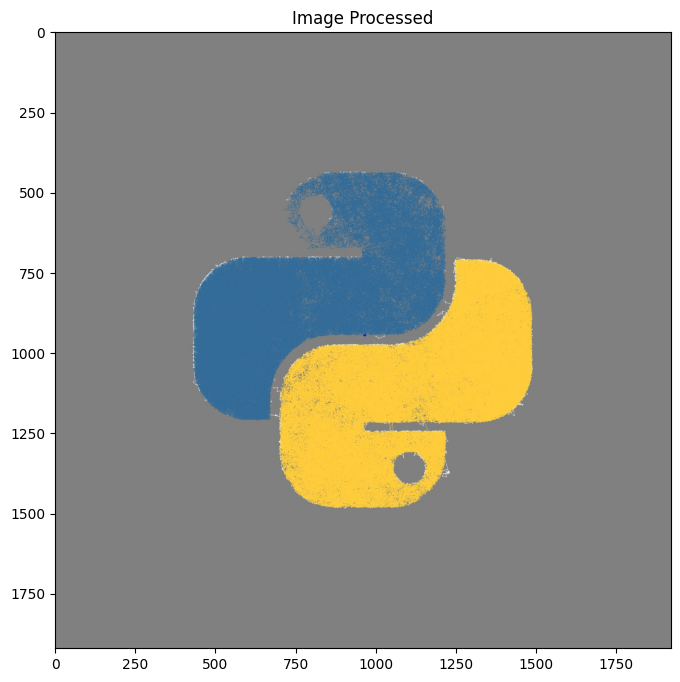

In [14]:
f, ax = plt.subplots(figsize=(12,8))

ax.set_title("Image Processed")
ax.imshow(img2)

## О том, где чаще бывает блуждание

Попробуем прогреть цепь и собрать семплы.

In [ ]:
inputFilename="./HSE.jpg"#"./test-images/HSE.jpg"#"./test-images/bbridge.jpg"
outputFilename="./HSEMCMCfied22222.jpg"
img = read_image(inputFilename)
#img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)#since opencv permutes channels to BGR, remove if colors are wrong

brightnessDensity = 1-np.mean(img,axis=-1)/255#darkness map
#brightnessDensity = np.mean(img,axis=-1)/255#brightness map

delta = 0.1

nAnchors = 1000
sigma=150
sigmaNoise=220
blend=True

startAt = 500000
takeEvery = 50000
onlyPoints = True
pointRadius = 5
nIterations=50000000
Ntrajs = 1

artist = RWMHSampleArtist(img,brightnessDensity)

In [ ]:
artist.drawImage(outputFilename,nIterations, Ntrajs=Ntrajs,blend=blend, scale=10, 
                 pointRadius=pointRadius,
                 onlyPoints=onlyPoints,
                 startAt=startAt,
                 takeEvery=takeEvery)

In [14]:
outputFilename="./HSEMCMCfied22222.jpg"
img2 = read_image(outputFilename)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)#since opencv permutes channels to BGR, remove if colors are wrong

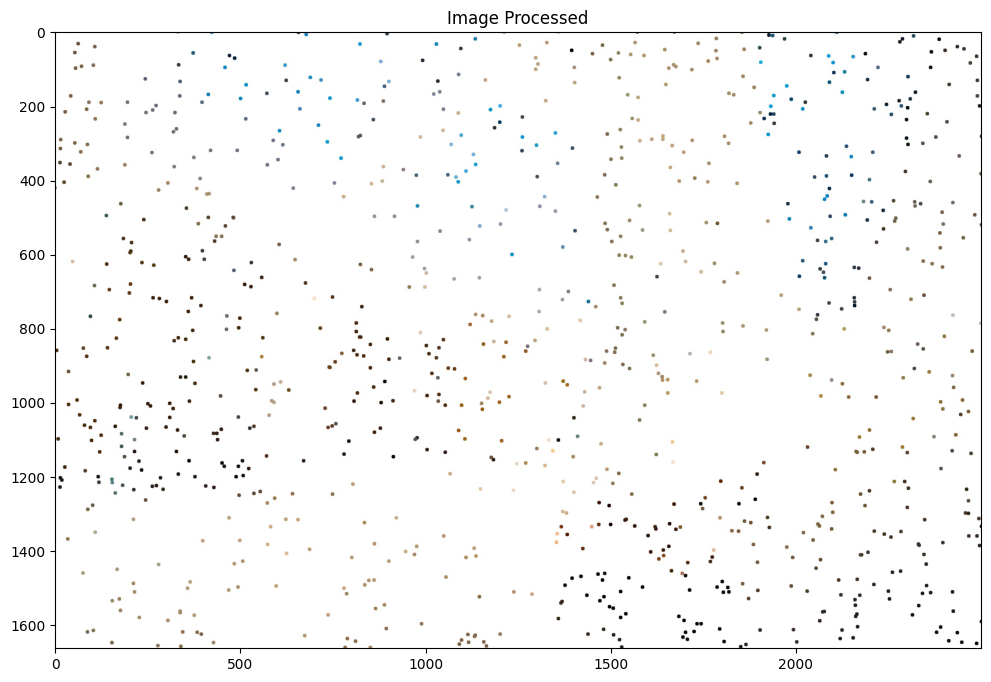

In [15]:
f, ax = plt.subplots(figsize=(12,8))

ax.set_title("Image Processed")
ax.imshow(img2)